In [1]:
!pip install yfinance


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

stock_data = yf.download('AAPL', start='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-02,270.756653,277.580254,268.748522,272.005484,37838100
2026-01-05,267.010162,271.256189,265.891214,270.387007,45647200
2026-01-06,262.114716,267.299866,261.874950,266.750392,52352100
2026-01-07,260.086609,263.433483,259.567106,262.953951,48309800
2026-01-08,258.797852,259.047618,255.460962,256.779720,50419300


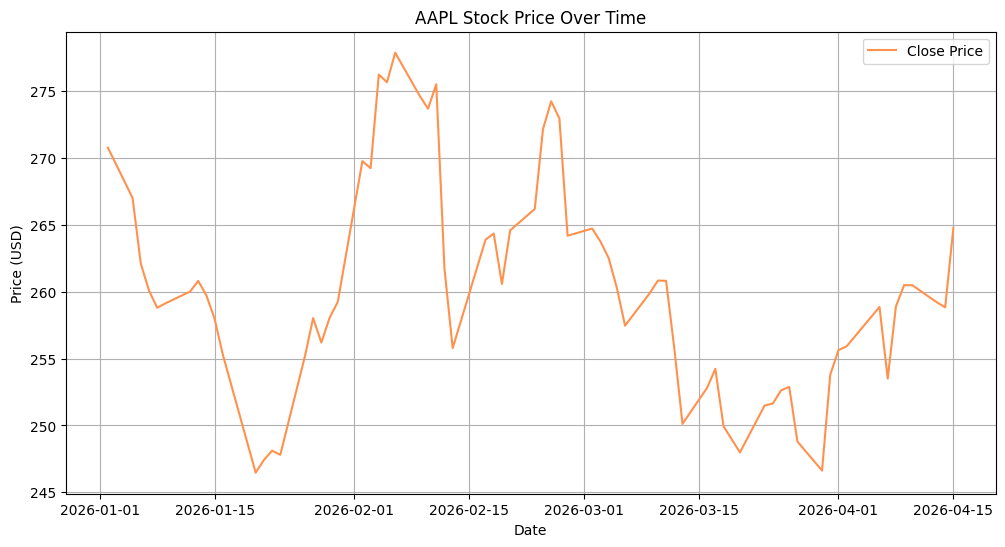

In [5]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='#FF914D')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Classical Time Series Decompostion

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model='additive', period=30)

In [7]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

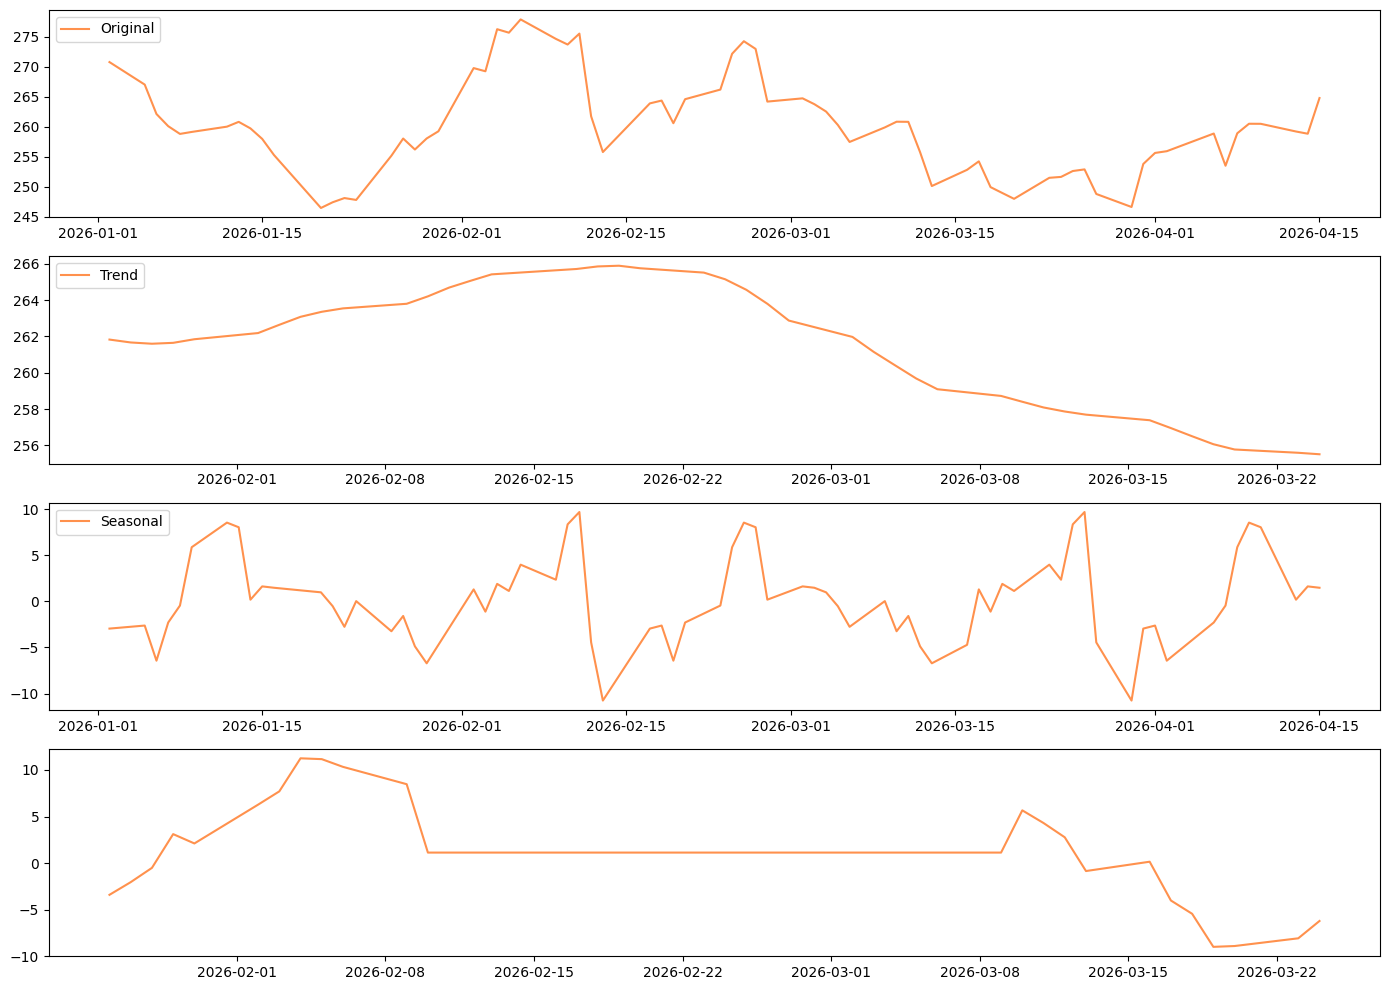

In [8]:
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_additive, label='Trend', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_additive, label='Residual', color='#FF914D')
plt.tight_layout()
plt.show()
